# Live2D SAM3 End-to-End Training, Inference, and GT Comparison

This notebook is the consolidated workflow for the current Live2D SAM3 experiment.

It can:

1. Check/build the hair-merged repeat-factor dataset.
2. Launch the RFS adapter fine-tune without overwriting `sam3.pt`.
3. Compare different `.pt` files/checkpoints on the same validation image.
4. Write prompt-bank COCO predictions, overlays, metrics, and GT difference images.

Default behavior is conservative: training is not launched until `RUN_TRAIN = True`.

In [1]:
from pathlib import Path
import contextlib
import hashlib
import json
import os
import random
import shutil
import subprocess
import sys

import numpy as np
import torch
from PIL import Image, ImageDraw
from IPython.display import display
from pycocotools import mask as mask_utils

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception as exc:
    HAS_MPL = False
    print('matplotlib unavailable:', exc)

try:
    import pandas as pd
    HAS_PANDAS = True
except Exception as exc:
    HAS_PANDAS = False
    print('pandas unavailable:', exc)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'sam3' / 'train' / 'train.py').exists():
            return candidate
    raise RuntimeError('Could not find the SAM3 repository root.')

ROOT = find_repo_root(Path.cwd())
os.chdir(ROOT)

LIVE2D_SCRIPT_DIR = ROOT / 'scripts' / 'live2d'
if str(LIVE2D_SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(LIVE2D_SCRIPT_DIR))

from evaluate_ground_truth import MaskItem, evaluate_threshold, load_gt, mask_to_bbox

BASE_CKPT = ROOT / 'sam3.pt'
BPE_PATH = ROOT / 'sam3' / 'assets' / 'bpe_simple_vocab_16e6.txt.gz'
HAIR_MERGED_TAXONOMY_PATH = ROOT / 'scripts' / 'live2d' / 'live2d_canonical_taxonomy_hair_merged.json'
CLOTHES_PARENT_TAXONOMY_PATH = ROOT / 'scripts' / 'live2d' / 'live2d_canonical_taxonomy_clothes_parent.json'

# Use the clothing-focused dataset/config by default. Set this to False to go
# back to the plain hair-merged RFS experiment.
USE_CLOTHES_PARENT = True

BASE_DATASET_ROOT = ROOT / 'dataset' / 'live2d_parts_canonical_hair_merged'
RFS_DATASET_ROOT = ROOT / 'dataset' / 'live2d_parts_canonical_hair_merged_rfs'
CLOTHES_PARENT_RFS_DATASET_ROOT = ROOT / 'dataset' / 'live2d_parts_canonical_hair_merged_clothes_parent_rfs'
CLOTHES_ALIAS_RFS_DATASET_ROOT = ROOT / 'dataset' / 'live2d_parts_canonical_hair_merged_clothes_alias_rfs'
CLOTHES_ALIAS_V2_RFS_DATASET_ROOT = ROOT / 'dataset' / 'live2d_parts_canonical_hair_merged_clothes_alias_v2_rfs'

V2_RUN_DIR = ROOT / 'runs' / 'live2d_parts_seg_adapter_hair_merged_25e'
RFS_RUN_DIR = ROOT / 'runs' / 'live2d_parts_seg_adapter_hair_merged_rfs_15e'
CLOTHES_PARENT_RUN_DIR = ROOT / 'runs' / 'live2d_parts_seg_adapter_clothes_parent_rfs_15e'
CLOTHES_ALIAS_RUN_DIR = ROOT / 'runs' / 'live2d_parts_seg_adapter_clothes_alias_rfs_5e'
CLOTHES_ALIAS_V2_RUN_DIR = ROOT / 'runs' / 'live2d_parts_seg_adapter_clothes_alias_v2_rfs_5e'

if USE_CLOTHES_PARENT:
    TAXONOMY_PATH = CLOTHES_PARENT_TAXONOMY_PATH
    DATASET_ROOT = CLOTHES_PARENT_RFS_DATASET_ROOT
    CONFIG = 'configs/live2d/live2d_parts_seg_adapter_clothes_parent_rfs_15e.yaml'
    RUN_DIR = CLOTHES_PARENT_RUN_DIR
else:
    TAXONOMY_PATH = HAIR_MERGED_TAXONOMY_PATH
    DATASET_ROOT = RFS_DATASET_ROOT
    CONFIG = 'configs/live2d/live2d_parts_seg_adapter_hair_merged_rfs_15e.yaml'
    RUN_DIR = RFS_RUN_DIR

CKPT_DIR = RUN_DIR / 'checkpoints'
LOG_DIR = RUN_DIR / 'logs' / 'live2d'
OUTPUT_DIR = ROOT / 'runs' / 'live2d_end_to_end_gt_compare'

STRICT_THRESHOLDS_PATH = ROOT / 'runs' / 'live2d_threshold_sweep' / 'trainer_v2_hair_merged_e25_iou050_nms050_per_class_thresholds.json'
SOFT_THRESHOLDS_PATH = ROOT / 'runs' / 'live2d_threshold_sweep' / 'trainer_v2_hair_merged_e25_iou025_nms050_per_class_thresholds.json'
CLOTHES_STRICT_THRESHOLDS_PATH = ROOT / 'runs' / 'live2d_threshold_sweep' / 'trainer_clothes_parent_e5_iou050_nms050_per_class_thresholds.json'
CLOTHES_SOFT_THRESHOLDS_PATH = ROOT / 'runs' / 'live2d_threshold_sweep' / 'trainer_clothes_parent_e5_iou025_nms050_per_class_thresholds.json'
PER_CLASS_THRESHOLDS_PATH = CLOTHES_SOFT_THRESHOLDS_PATH if USE_CLOTHES_PARENT else SOFT_THRESHOLDS_PATH

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['PYTHONUTF8'] = '1'
os.environ['PYTHONIOENCODING'] = 'utf-8'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('repo:', ROOT)
print('device:', DEVICE)
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))
print('dataset:', DATASET_ROOT)
print('config:', ROOT / 'sam3' / 'train' / CONFIG)
print('output:', OUTPUT_DIR)

repo: D:\github\sam3
device: cuda
gpu: NVIDIA GeForce RTX 5080
dataset: D:\github\sam3\dataset\live2d_parts_canonical_hair_merged_clothes_parent_rfs
config: D:\github\sam3\sam3\train\configs\live2d\live2d_parts_seg_adapter_clothes_parent_rfs_15e.yaml
output: D:\github\sam3\runs\live2d_end_to_end_gt_compare


## 1. Dataset Check / Build

The notebook uses the hair-merged v2 taxonomy and the repeat-factor sampled training split. If the RFS dataset is missing, this cell can build it from the canonical hair-merged dataset.

In [2]:

BUILD_RFS_IF_MISSING = True
REBUILD_RFS = False
BUILD_CLOTHES_PARENT_IF_MISSING = True
REBUILD_CLOTHES_PARENT = False
RFS_TARGET_FRACTION = 0.4
RFS_MAX_REPEAT = 4


def run_command(cmd, *, cwd=ROOT, env=None):
    print('running:', ' '.join(str(x) for x in cmd))
    result = subprocess.run(cmd, cwd=cwd, env=env or os.environ.copy())
    print('return code:', result.returncode)
    if result.returncode != 0:
        raise RuntimeError(f'Command failed: {cmd}')
    return result

if REBUILD_RFS or (BUILD_RFS_IF_MISSING and not (RFS_DATASET_ROOT / 'train' / '_annotations.coco.json').exists()):
    cmd = [
        sys.executable,
        'scripts/live2d/make_repeat_factor_coco.py',
        '--input-root', str(BASE_DATASET_ROOT),
        '--output-root', str(RFS_DATASET_ROOT),
        '--target-fraction', str(RFS_TARGET_FRACTION),
        '--max-repeat', str(RFS_MAX_REPEAT),
        '--overwrite',
    ]
    run_command(cmd)
else:
    print('RFS dataset already exists:', RFS_DATASET_ROOT)

if USE_CLOTHES_PARENT:
    parent_ann = CLOTHES_PARENT_RFS_DATASET_ROOT / 'train' / '_annotations.coco.json'
    if REBUILD_CLOTHES_PARENT or (BUILD_CLOTHES_PARENT_IF_MISSING and not parent_ann.exists()):
        cmd = [
            sys.executable,
            'scripts/live2d/add_parent_category_masks.py',
            '--input-root', str(RFS_DATASET_ROOT),
            '--output-root', str(CLOTHES_PARENT_RFS_DATASET_ROOT),
            '--parent-name', 'clothes',
            '--child-names', 'upper clothes', 'lower clothes',
            '--overwrite',
        ]
        run_command(cmd)
    else:
        print('clothes-parent dataset already exists:', CLOTHES_PARENT_RFS_DATASET_ROOT)


def summarize_coco(split: str):
    ann_path = DATASET_ROOT / split / '_annotations.coco.json'
    data = json.loads(ann_path.read_text(encoding='utf-8'))
    counts = {}
    cat_names = {int(c['id']): c['name'] for c in data['categories']}
    for ann in data['annotations']:
        name = cat_names[int(ann['category_id'])]
        counts[name] = counts.get(name, 0) + 1
    return {
        'split': split,
        'images': len(data['images']),
        'annotations': len(data['annotations']),
        'categories': len(data['categories']),
        'top_counts': dict(sorted(counts.items(), key=lambda kv: -kv[1])[:10]),
        'clothing_counts': {name: counts.get(name, 0) for name in ['clothes', 'upper clothes', 'lower clothes']},
    }

for split in ['train', 'val', 'test']:
    print(json.dumps(summarize_coco(split), ensure_ascii=False, indent=2))


RFS dataset already exists: D:\github\sam3\dataset\live2d_parts_canonical_hair_merged_rfs
clothes-parent dataset already exists: D:\github\sam3\dataset\live2d_parts_canonical_hair_merged_clothes_parent_rfs
{
  "split": "train",
  "images": 28,
  "annotations": 332,
  "categories": 21,
  "top_counts": {
    "mouth": 25,
    "face": 24,
    "eyes": 23,
    "ears": 22,
    "eyebrows": 21,
    "hair": 21,
    "neck": 20,
    "arms": 19,
    "legs": 19,
    "clothes": 19
  },
  "clothing_counts": {
    "clothes": 19,
    "upper clothes": 17,
    "lower clothes": 8
  }
}
{
  "split": "val",
  "images": 2,
  "annotations": 24,
  "categories": 21,
  "top_counts": {
    "face": 2,
    "eyes": 2,
    "eyebrows": 2,
    "mouth": 2,
    "hair": 2,
    "torso": 2,
    "accessory": 1,
    "cheek": 1,
    "neck": 1,
    "iris": 1
  },
  "clothing_counts": {
    "clothes": 1,
    "upper clothes": 1,
    "lower clothes": 1
  }
}
{
  "split": "test",
  "images": 2,
  "annotations": 21,
  "categories": 2

## 2. Optional Training

Set `RUN_TRAIN = True` to launch the RFS 15-epoch adapter fine-tune. The base `sam3.pt` is only read, never overwritten. Checkpoints are written under `runs/live2d_parts_seg_adapter_hair_merged_rfs_15e/checkpoints`.

In [3]:
RUN_TRAIN = False
FRESH_RUN = False


def sha256_file(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

required = [
    BASE_CKPT,
    BPE_PATH,
    TAXONOMY_PATH,
    DATASET_ROOT / 'train' / '_annotations.coco.json',
    ROOT / 'sam3' / 'train' / CONFIG,
]
for path in required:
    print(path, 'OK' if path.exists() else 'MISSING')

base_hash_before = sha256_file(BASE_CKPT)
print('sam3.pt sha256 before:', base_hash_before)

if FRESH_RUN and RUN_DIR.exists():
    resolved_run = RUN_DIR.resolve()
    resolved_root = ROOT.resolve()
    assert resolved_root in resolved_run.parents, f'Unsafe run dir: {resolved_run}'
    assert resolved_run.name == RUN_DIR.name, f'Unexpected run dir: {resolved_run}'
    shutil.rmtree(resolved_run)
    print('removed:', resolved_run)

TRAIN_CMD = [sys.executable, 'sam3/train/train.py', '-c', CONFIG, '--use-cluster', '0', '--num-gpus', '1']

if RUN_TRAIN:
    env = os.environ.copy()
    env['PYTHONUTF8'] = '1'
    env['PYTHONIOENCODING'] = 'utf-8'
    run_command(TRAIN_CMD, env=env)
else:
    print('training not launched. Set RUN_TRAIN = True to run:')
    print(' '.join(TRAIN_CMD))

base_hash_after = sha256_file(BASE_CKPT)
print('sam3.pt sha256 after:', base_hash_after)
assert base_hash_before == base_hash_after, 'sam3.pt changed; stop and inspect.'

if CKPT_DIR.exists():
    for ckpt in sorted(CKPT_DIR.glob('checkpoint*.pt')):
        print(ckpt.name, f'{ckpt.stat().st_size / (1024 * 1024):.2f} MB')
else:
    print('checkpoint directory not found yet:', CKPT_DIR)

D:\github\sam3\sam3.pt OK
D:\github\sam3\sam3\assets\bpe_simple_vocab_16e6.txt.gz OK
D:\github\sam3\scripts\live2d\live2d_canonical_taxonomy_clothes_parent.json OK
D:\github\sam3\dataset\live2d_parts_canonical_hair_merged_clothes_parent_rfs\train\_annotations.coco.json OK
D:\github\sam3\sam3\train\configs\live2d\live2d_parts_seg_adapter_clothes_parent_rfs_15e.yaml OK


sam3.pt sha256 before: 9999e2341ceef5e136daa386eecb55cb414446a00ac2b55eb2dfd2f7c3cf8c9e
training not launched. Set RUN_TRAIN = True to run:
d:\github\sam3\.venv\Scripts\python.exe sam3/train/train.py -c configs/live2d/live2d_parts_seg_adapter_clothes_parent_rfs_15e.yaml --use-cluster 0 --num-gpus 1


sam3.pt sha256 after: 9999e2341ceef5e136daa386eecb55cb414446a00ac2b55eb2dfd2f7c3cf8c9e
checkpoint.pt 35.38 MB
checkpoint_10.pt 35.38 MB
checkpoint_5.pt 35.38 MB


## 3. Training Curves / Trainer Eval Summary

This cell reads JSONL train/val logs for the RFS run if they exist.

train rows: 10 val rows: 1
{'epoch': 5, 'loss': 531.4719837733677, 'mask': 0.007359993856100898, 'dice': 0.3961316528064864, 'ce_f1': 0.3531323399926935}
{'epoch': 6, 'loss': 534.8151038033621, 'mask': 0.007669160441894617, 'dice': 0.414755716919899, 'ce_f1': 0.3659985044172832}
{'epoch': 7, 'loss': 533.3680910382952, 'mask': 0.007985373717799251, 'dice': 0.40619096159935, 'ce_f1': 0.3692807624382632}
{'epoch': 8, 'loss': 528.9856774466379, 'mask': 0.0077334892017201385, 'dice': 0.399608487529414, 'ce_f1': 0.3608603227351393}
{'epoch': 9, 'loss': 529.7554223196847, 'mask': 0.007348586364449667, 'dice': 0.4041738962488515, 'ce_f1': 0.3511879867208855}
{'epoch': 5, 'AP': 0.052016868353502006, 'AP50': 0.10198936560322698}


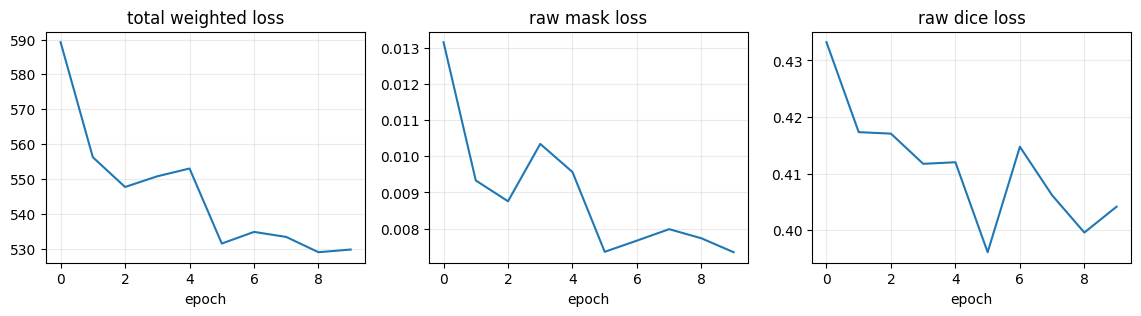

In [4]:
def load_jsonl(path: Path):
    if not path.exists():
        return []
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows

train_rows = load_jsonl(LOG_DIR / 'train_stats.json')
val_rows = load_jsonl(LOG_DIR / 'val_stats.json')
print('train rows:', len(train_rows), 'val rows:', len(val_rows))

for row in train_rows[-5:]:
    print({
        'epoch': row.get('Trainer/epoch'),
        'loss': row.get('Losses/train_all_loss'),
        'mask': row.get('Losses/train_all_loss_mask'),
        'dice': row.get('Losses/train_all_loss_dice'),
        'ce_f1': row.get('Losses/train_all_ce_f1'),
    })

for row in val_rows[-5:]:
    print({
        'epoch': row.get('Trainer/epoch'),
        'AP': row.get('Meters_train\\val_live2d/detection\\coco_eval_segm_AP'),
        'AP50': row.get('Meters_train\\val_live2d/detection\\coco_eval_segm_AP_50'),
    })

if HAS_MPL and train_rows:
    epochs = [r.get('Trainer/epoch') for r in train_rows]
    loss = [r.get('Losses/train_all_loss') for r in train_rows]
    mask_loss = [r.get('Losses/train_all_loss_mask') for r in train_rows]
    dice_loss = [r.get('Losses/train_all_loss_dice') for r in train_rows]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    axes[0].plot(epochs, loss)
    axes[0].set_title('total weighted loss')
    axes[1].plot(epochs, mask_loss)
    axes[1].set_title('raw mask loss')
    axes[2].plot(epochs, dice_loss)
    axes[2].set_title('raw dice loss')
    for ax in axes:
        ax.set_xlabel('epoch')
        ax.grid(True, alpha=0.25)
    plt.show()

## 4. Select GT Image, Prompt Bank, and Postprocess Policy

When `IMAGE_FILE_NAME` is `None`, the notebook now chooses the first validation image that actually has `clothes` / `upper clothes` / `lower clothes` GT. That avoids judging clothing quality on PSDs whose layer structure only has a flattened `body/torso` layer. `POSTPROCESS_PRESET = 'clothing_debug'` keeps lower-score clothing candidates and overrides the old strict per-class sweep that suppressed clothing outputs.


image: D:\github\sam3\dataset\live2d_parts_canonical_hair_merged_clothes_parent_rfs\val\ff01_final_015eaf31.png (5000, 7000) gt image id: 2
val images with clothing GT: ['ff01_final_015eaf31.png']
taxonomy: D:\github\sam3\scripts\live2d\live2d_canonical_taxonomy_clothes_parent.json
postprocess preset: clothing_debug threshold file: D:\github\sam3\runs\live2d_threshold_sweep\trainer_clothes_parent_e5_iou025_nms050_per_class_thresholds.json
threshold overrides: {'clothes': 0.2, 'upper clothes': 0.22, 'lower clothes': 0.2, 'torso': 0.45}
processor confidence threshold: 0.2
prompt class preset: clothing_focus ['clothes', 'upper clothes', 'lower clothes', 'torso']
compare model preset: clothing_quick
prompt classes: 4
clothing prompts:
clothes       : ['clothes', 'garment', 'visible clothing', 'clothing pieces', 'character garment', 'clothing']
upper clothes : ['upper clothes', 'bodice', 'dress top', 'upper garment', 'shirt', 'blouse']
lower clothes : ['lower clothes', 'skirt', 'dress skirt

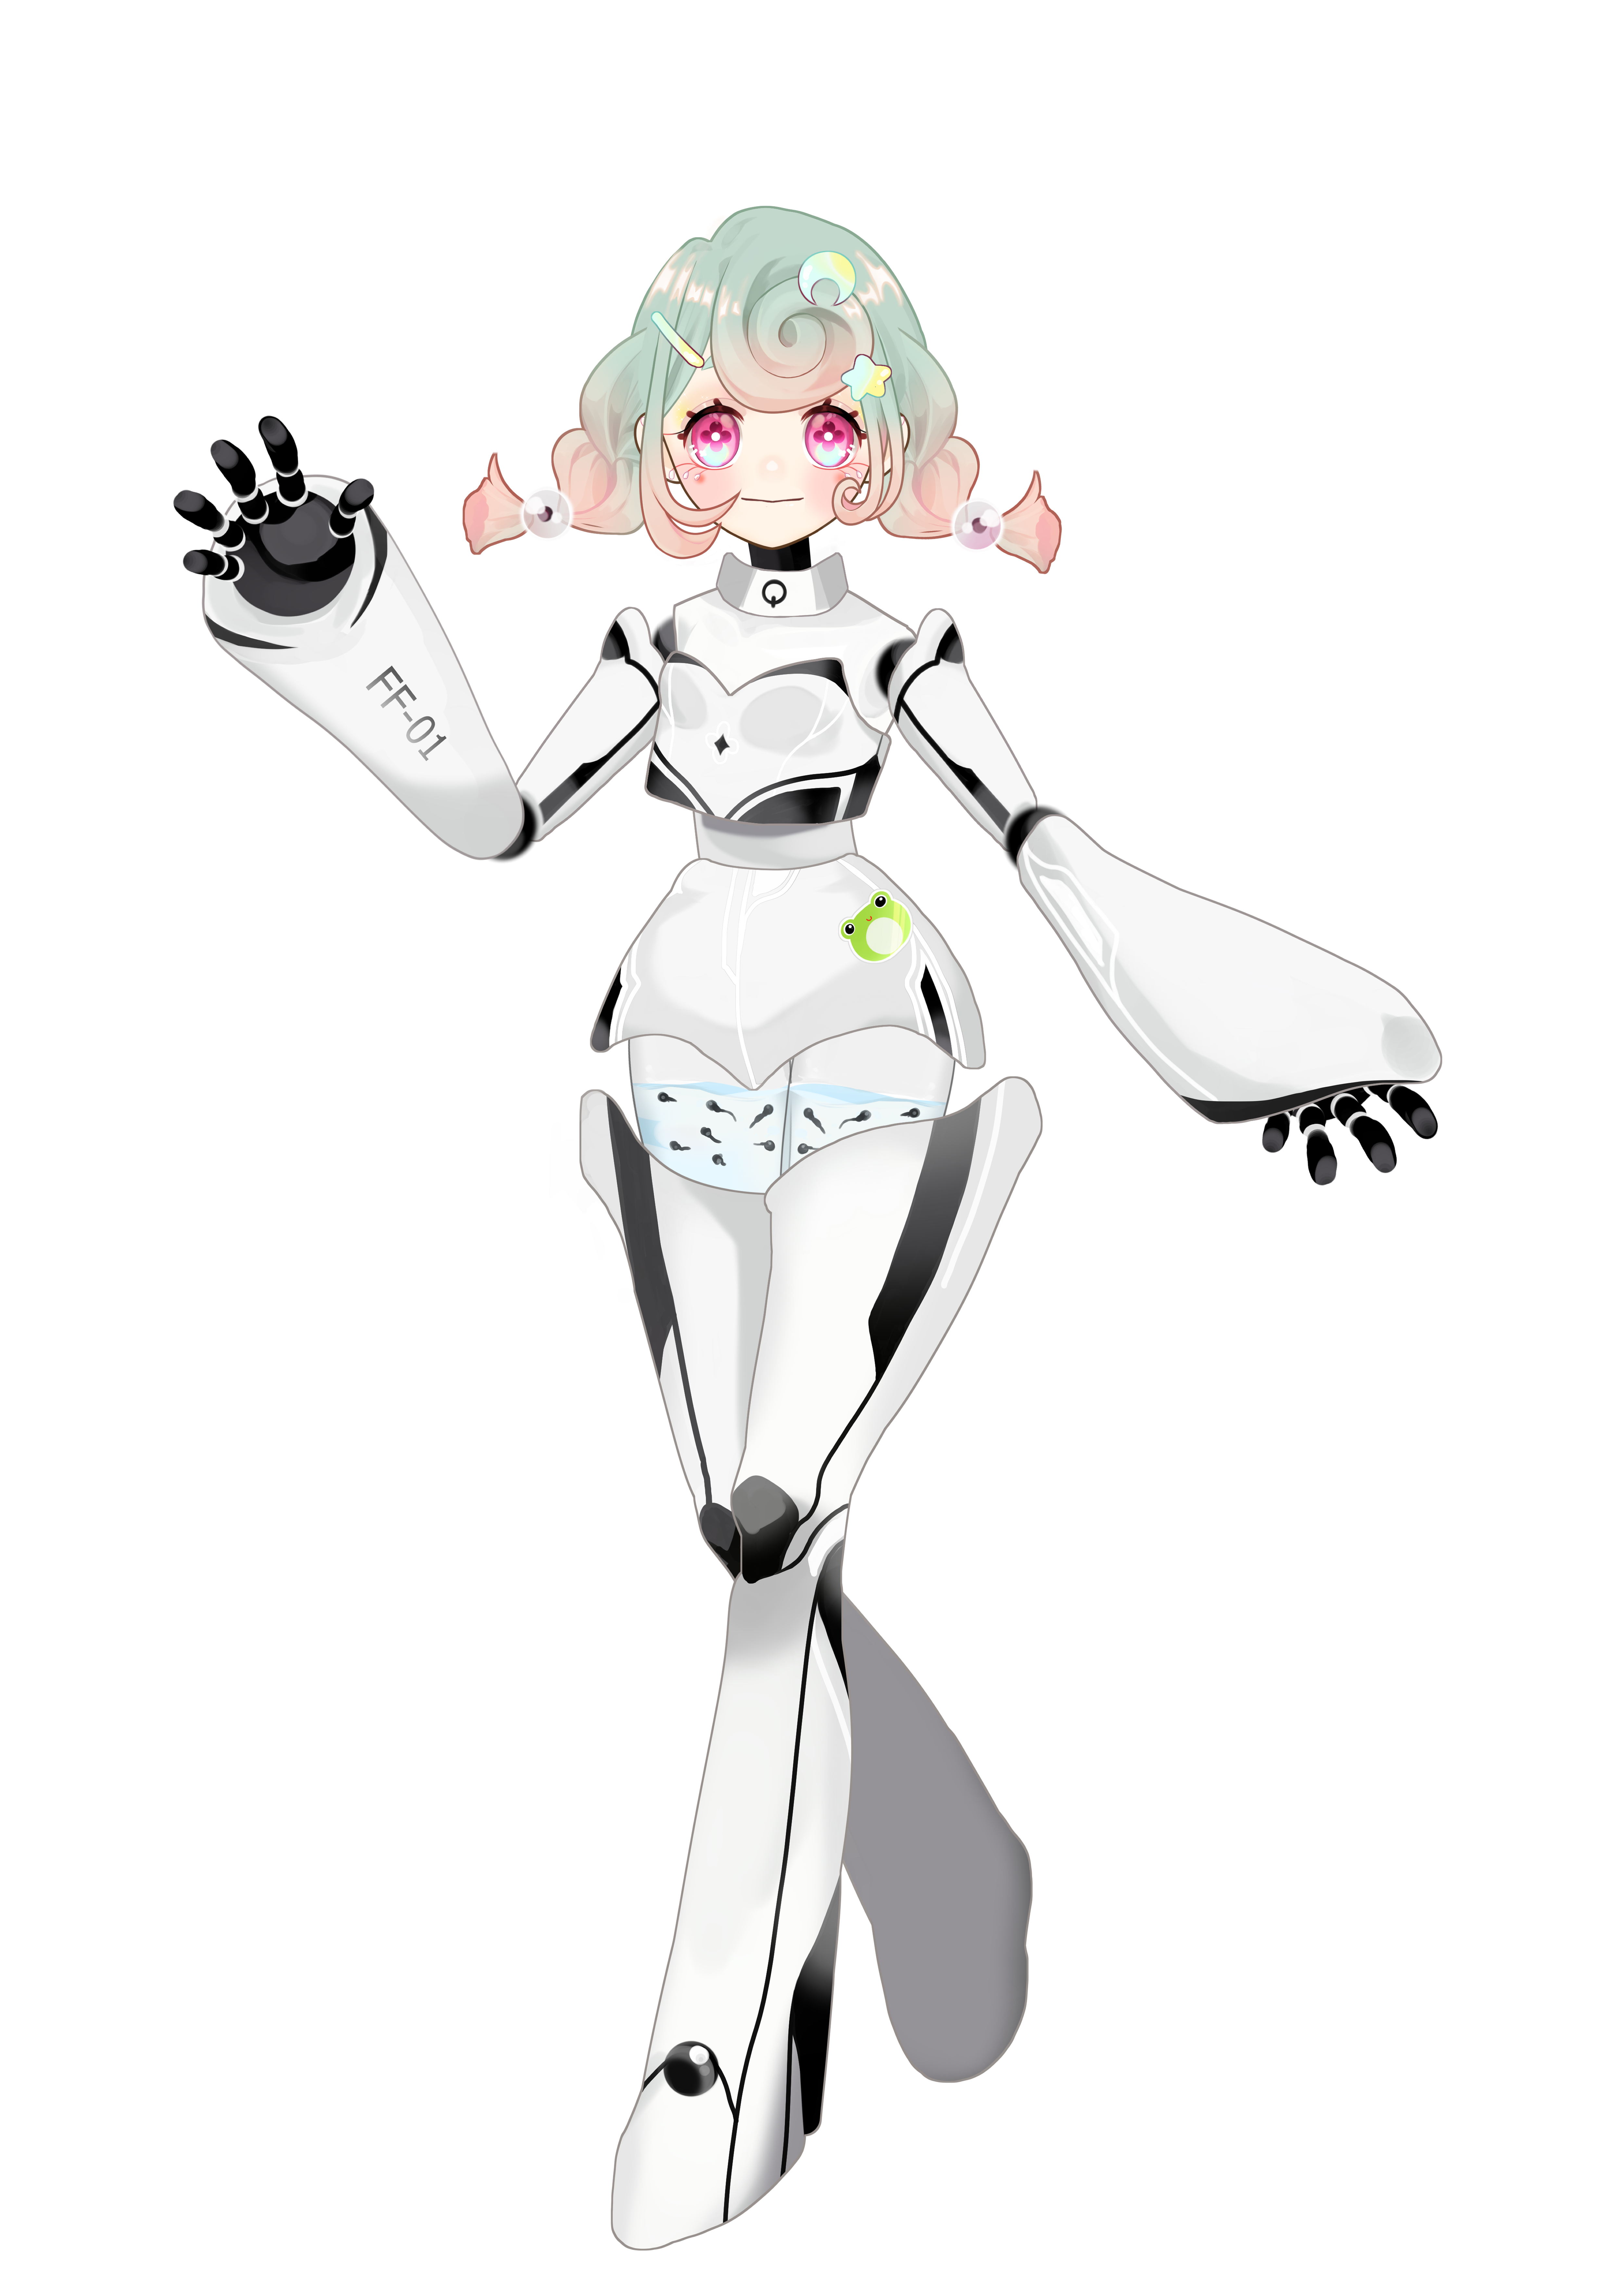

In [5]:

IMAGE_FILE_NAME = None  # None means first val image; or set an exact filename from val split.
PROMPT_MAX_ALIASES = 6
PROCESSOR_CONFIDENCE_THRESHOLD = 0.20
IOU_DEDUP_THRESHOLD = 0.5
MIN_MASK_AREA = 16
POSTPROCESS_PRESET = 'clothing_debug'  # 'clothing_debug', 'strict_iou050', 'soft_iou025', or 'global'
GLOBAL_SCORE_THRESHOLD = 0.70
RUN_PROMPT_INFERENCE = True
PROMPT_CLASS_PRESET = 'clothing_focus'  # 'clothing_focus' or 'all'
COMPARE_MODEL_PRESET = 'clothing_quick'  # 'clothing_quick' or 'discovered'
CHECKPOINT_MODE = 'selected_epochs'  # 'finals', 'selected_epochs', or 'all_epochs'
SELECTED_EPOCHS = [5, 10, 15, 20, 25]
MAX_COMPARE_MODELS = 24

CLOTHING_CLASS_NAMES = ['clothes', 'upper clothes', 'lower clothes']
PROMPT_OVERRIDES = {
    'clothes': [
        'garment', 'visible clothing', 'clothing pieces', 'character garment',
        'clothing', 'clothes', 'costume', 'dress', 'uniform', 'apparel',
    ],
    'upper clothes': [
        'bodice', 'dress top', 'upper garment', 'shirt', 'blouse',
        'upper clothes', 'jacket', 'coat', 'upper outfit',
    ],
    'lower clothes': [
        'skirt', 'dress skirt', 'lower garment', 'lower clothes',
        'pants', 'shorts', 'lower outfit',
    ],
}

ACTIVE_STRICT_THRESHOLDS_PATH = (
    CLOTHES_STRICT_THRESHOLDS_PATH
    if USE_CLOTHES_PARENT and CLOTHES_STRICT_THRESHOLDS_PATH.exists()
    else STRICT_THRESHOLDS_PATH
)
ACTIVE_SOFT_THRESHOLDS_PATH = (
    CLOTHES_SOFT_THRESHOLDS_PATH
    if USE_CLOTHES_PARENT and CLOTHES_SOFT_THRESHOLDS_PATH.exists()
    else SOFT_THRESHOLDS_PATH
)

if POSTPROCESS_PRESET == 'strict_iou050':
    PER_CLASS_THRESHOLDS_PATH = ACTIVE_STRICT_THRESHOLDS_PATH
    THRESHOLD_OVERRIDES = {}
elif POSTPROCESS_PRESET == 'soft_iou025':
    PER_CLASS_THRESHOLDS_PATH = ACTIVE_SOFT_THRESHOLDS_PATH
    THRESHOLD_OVERRIDES = {}
elif POSTPROCESS_PRESET == 'clothing_debug':
    PER_CLASS_THRESHOLDS_PATH = ACTIVE_SOFT_THRESHOLDS_PATH
    THRESHOLD_OVERRIDES = {
        # Keep whole-outfit masks; the clothes-parent sweep currently prefers 0.50,
        # but prompt-bank inference often scores lower than trainer dumps.
        'clothes': 0.20,
        'upper clothes': 0.22,
        'lower clothes': 0.20,
        # Torso often absorbs clothing. Keep it slightly stricter during clothing diagnosis.
        'torso': 0.45,
    }
elif POSTPROCESS_PRESET == 'global':
    PER_CLASS_THRESHOLDS_PATH = None
    THRESHOLD_OVERRIDES = {}
else:
    raise ValueError(f'Unknown POSTPROCESS_PRESET: {POSTPROCESS_PRESET}')

taxonomy = json.loads(TAXONOMY_PATH.read_text(encoding='utf-8'))
categories = taxonomy['categories']
category_by_id = {int(c['id']): c['name'] for c in categories}
category_by_name = {c['name']: c for c in categories}

val_coco = json.loads((DATASET_ROOT / 'val' / '_annotations.coco.json').read_text(encoding='utf-8'))
val_cat_names = {int(c['id']): c['name'] for c in val_coco['categories']}
val_image_by_id = {int(img['id']): img for img in val_coco['images']}
clothing_image_ids = {
    int(ann['image_id'])
    for ann in val_coco['annotations']
    if val_cat_names[int(ann['category_id'])] in CLOTHING_CLASS_NAMES
}
if IMAGE_FILE_NAME is None:
    image_info = next(
        (val_image_by_id[image_id] for image_id in sorted(clothing_image_ids)),
        val_coco['images'][0],
    )
else:
    image_info = next(img for img in val_coco['images'] if img['file_name'] == IMAGE_FILE_NAME)
IMAGE_FILE_NAME = image_info['file_name']
GT_IMAGE_ID = int(image_info['id'])
IMAGE_PATH = DATASET_ROOT / 'val' / IMAGE_FILE_NAME
image = Image.open(IMAGE_PATH).convert('RGB')
width, height = image.size

if PROMPT_CLASS_PRESET == 'clothing_focus':
    PROMPT_CLASSES = [
        name
        for name in ['clothes', 'upper clothes', 'lower clothes', 'torso']
        if name in category_by_name
    ]
elif PROMPT_CLASS_PRESET == 'all':
    PROMPT_CLASSES = [c['name'] for c in categories]
else:
    raise ValueError(f'Unknown PROMPT_CLASS_PRESET: {PROMPT_CLASS_PRESET}')


def build_prompt_bank(categories, max_aliases=3):
    bank = {}
    for category in categories:
        name = category['name']
        prompts = []
        seen = set()
        seed_values = [name, *PROMPT_OVERRIDES.get(name, []), *category.get('aliases', [])]
        for value in seed_values:
            value = str(value).replace('_', ' ').strip()
            key = value.casefold()
            if value and key not in seen:
                prompts.append(value)
                seen.add(key)
        ascii_prompts = [p for p in prompts if p.isascii()]
        non_ascii_prompts = [p for p in prompts if not p.isascii()]
        ordered = ascii_prompts + non_ascii_prompts
        bank[name] = ordered[:max_aliases] if max_aliases else ordered
    return bank

prompt_categories = [category_by_name[name] for name in PROMPT_CLASSES if name in category_by_name]
prompt_bank = build_prompt_bank(prompt_categories, PROMPT_MAX_ALIASES)

print('image:', IMAGE_PATH, image.size, 'gt image id:', GT_IMAGE_ID)
print('val images with clothing GT:', [val_image_by_id[i]['file_name'] for i in sorted(clothing_image_ids)])
print('taxonomy:', TAXONOMY_PATH)
print('postprocess preset:', POSTPROCESS_PRESET, 'threshold file:', PER_CLASS_THRESHOLDS_PATH)
print('threshold overrides:', THRESHOLD_OVERRIDES)
print('processor confidence threshold:', PROCESSOR_CONFIDENCE_THRESHOLD)
print('prompt class preset:', PROMPT_CLASS_PRESET, PROMPT_CLASSES)
print('compare model preset:', COMPARE_MODEL_PRESET)
print('prompt classes:', len(prompt_categories))
print('clothing prompts:')
for name in CLOTHING_CLASS_NAMES:
    if name in prompt_bank:
        print(f'{name:14s}: {prompt_bank[name]}')
print('first prompt classes:')
for name, prompts in list(prompt_bank.items())[:8]:
    print(f'{name:14s}: {prompts}')
display(image)


## 5. Inference and Rendering Utilities

This section defines prompt-bank inference, COCO export, class-aware GT metrics, and the GT/prediction difference image renderer.

In [6]:
def inference_precision_context():
    if DEVICE == 'cuda':
        return torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16)
    return contextlib.nullcontext()


def tensor_to_numpy(value):
    if value is None:
        return None
    if isinstance(value, torch.Tensor):
        value = value.detach()
        if value.dtype == torch.bfloat16:
            value = value.float()
        return value.cpu().numpy()
    return np.asarray(value)


def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union else 0.0


def dedupe_predictions(predictions, threshold=0.85):
    kept = []
    for pred in sorted(predictions, key=lambda x: x['score'], reverse=True):
        same_class = [p for p in kept if p['category_id'] == pred['category_id']]
        if any(mask_iou(pred['mask'], p['mask']) >= threshold for p in same_class):
            continue
        kept.append(pred)
    return kept


def encode_rle(mask):
    encoded = mask_utils.encode(np.asfortranarray(mask.astype(np.uint8)))
    encoded['counts'] = encoded['counts'].decode('ascii')
    return encoded


def load_per_class_thresholds(path):
    if path is None or not Path(path).exists():
        return {}
    payload = json.loads(Path(path).read_text(encoding='utf-8'))
    return {str(k): float(v) for k, v in payload.get('category_thresholds_by_name', {}).items()}

PER_CLASS_THRESHOLDS_BY_NAME = load_per_class_thresholds(PER_CLASS_THRESHOLDS_PATH)
print('loaded thresholds:', PER_CLASS_THRESHOLDS_BY_NAME)
print('manual threshold overrides:', THRESHOLD_OVERRIDES)


def score_threshold_for(category_name):
    if category_name in THRESHOLD_OVERRIDES:
        return THRESHOLD_OVERRIDES[category_name]
    if POSTPROCESS_PRESET == 'global':
        return GLOBAL_SCORE_THRESHOLD
    return PER_CLASS_THRESHOLDS_BY_NAME.get(category_name, GLOBAL_SCORE_THRESHOLD)


def filter_predictions_by_score(predictions):
    return [pred for pred in predictions if pred['score'] >= score_threshold_for(pred['category_name'])]


def state_to_predictions(state, category, prompt):
    masks = tensor_to_numpy(state.get('masks'))
    boxes = tensor_to_numpy(state.get('boxes'))
    scores = tensor_to_numpy(state.get('scores'))
    if masks is None or len(masks) == 0:
        return []
    masks = np.asarray(masks).astype(bool)
    if masks.ndim == 4:
        masks = masks[:, 0]
    if boxes is None:
        boxes = np.array([mask_to_bbox(mask) for mask in masks], dtype=np.float32)
    if scores is None:
        scores = np.ones((len(masks),), dtype=np.float32)
    preds = []
    for mask, box, score in zip(masks, boxes, scores):
        area = int(mask.sum())
        if area < MIN_MASK_AREA:
            continue
        preds.append({
            'image_id': GT_IMAGE_ID,
            'category_id': int(category['id']),
            'category_name': category['name'],
            'prompt': prompt,
            'score': float(score),
            'bbox_xyxy': [float(x) for x in box.tolist()],
            'mask': mask,
            'area': area,
        })
    return preds


def predictions_to_coco(predictions, image_info, categories):
    annotations = []
    for ann_id, pred in enumerate(predictions, start=1):
        mask = pred['mask']
        annotations.append({
            'id': ann_id,
            'image_id': int(image_info['id']),
            'category_id': int(pred['category_id']),
            'segmentation': encode_rle(mask),
            'area': int(mask.sum()),
            'bbox': mask_to_bbox(mask),
            'iscrowd': 0,
            'score': float(pred['score']),
            'attributes': {'category_name': pred['category_name'], 'prompt': pred['prompt']},
        })
    return {
        'images': [image_info],
        'annotations': annotations,
        'categories': [{'id': int(c['id']), 'name': c['name'], 'supercategory': 'live2d_part'} for c in categories],
    }


def predictions_to_mask_items(predictions):
    return [
        MaskItem(
            image_id=int(pred['image_id']),
            category_id=int(pred['category_id']),
            mask=pred['mask'],
            score=float(pred['score']),
            area=int(pred['area']),
            ann_id=idx,
        )
        for idx, pred in enumerate(predictions, start=1)
    ]

def prediction_fingerprint(predictions):
    compact = []
    for pred in sorted(predictions, key=lambda p: (p['category_id'], -p['score'], p['area'])):
        bbox = mask_to_bbox(pred['mask'])
        compact.append({
            'category_id': int(pred['category_id']),
            'category_name': pred['category_name'],
            'score': round(float(pred['score']), 6),
            'area': int(pred['area']),
            'bbox': [round(float(v), 2) for v in bbox],
            'rle_counts_head': encode_rle(pred['mask'])['counts'][:80],
        })
    payload = json.dumps(compact, sort_keys=True, ensure_ascii=False).encode('utf-8')
    return hashlib.sha256(payload).hexdigest()[:16]


def category_counts(predictions):
    counts = {}
    for pred in predictions:
        counts[pred['category_name']] = counts.get(pred['category_name'], 0) + 1
    return dict(sorted(counts.items()))


def score_list(predictions):
    return [round(float(pred['score']), 4) for pred in sorted(predictions, key=lambda p: (p['category_name'], -p['score']))]


loaded thresholds: {'face': 0.7, 'neck': 0.65, 'eyes': 0.75, 'iris': 1.01, 'eyebrows': 1.01, 'nose': 0.45, 'mouth': 1.01, 'hair': 0.75, 'upper clothes': 0.6, 'lower clothes': 1.01, 'arms': 0.55, 'hands': 0.8, 'legs': 0.55, 'feet': 1.01, 'shoes': 1.01, 'ears': 1.01, 'tail': 1.01, 'accessory': 0.45, 'torso': 0.4, 'cheek': 0.45, 'clothes': 0.5}
manual threshold overrides: {'clothes': 0.2, 'upper clothes': 0.22, 'lower clothes': 0.2, 'torso': 0.45}


In [7]:
def color_for_category(category_id):
    rng = random.Random(category_id * 1009)
    return tuple(rng.randint(40, 235) for _ in range(3))


def add_banner(panel, title):
    banner = Image.new('RGB', (panel.width, 42), (28, 28, 28))
    draw = ImageDraw.Draw(banner)
    draw.text((10, 13), title, fill=(255, 255, 255))
    out = Image.new('RGB', (panel.width, panel.height + banner.height), (255, 255, 255))
    out.paste(banner, (0, 0))
    out.paste(panel.convert('RGB'), (0, banner.height))
    return out


def fit_width(panel, target_width=720):
    if panel.width <= target_width:
        return panel.convert('RGB')
    scale = target_width / panel.width
    return panel.resize((target_width, max(1, int(panel.height * scale))), Image.Resampling.LANCZOS).convert('RGB')


def render_mask_overlay(base_image, items, title, alpha=120, max_labels=80):
    base = base_image.convert('RGBA')
    overlay = Image.new('RGBA', base.size, (0, 0, 0, 0))
    for item in sorted(items, key=lambda x: x.area, reverse=True):
        color = color_for_category(item.category_id)
        mask_img = Image.fromarray((item.mask * alpha).astype(np.uint8), mode='L')
        fill = Image.new('RGBA', base.size, (*color, 0))
        fill.putalpha(mask_img)
        overlay = Image.alpha_composite(overlay, fill)
    out = Image.alpha_composite(base, overlay).convert('RGB')
    draw = ImageDraw.Draw(out)
    for item in sorted(items, key=lambda x: x.area, reverse=True)[:max_labels]:
        x, y, w, h = mask_to_bbox(item.mask)
        color = color_for_category(item.category_id)
        draw.rectangle([x, y, x + w, y + h], outline=color, width=3)
        label = category_by_id.get(item.category_id, str(item.category_id))
        if item.score < 0.999:
            label = f'{label} {item.score:.2f}'
        draw.text((x + 2, y + 2), label, fill=(255, 255, 255), stroke_width=2, stroke_fill=(0, 0, 0))
    return add_banner(out, title)


def union_by_category(items, shape):
    h, w = shape
    out = {cid: np.zeros((h, w), dtype=bool) for cid in category_by_id}
    for item in items:
        out.setdefault(item.category_id, np.zeros((h, w), dtype=bool))
        out[item.category_id] |= item.mask.astype(bool)
    return out


def render_diff_panel(base_image, gt_items, pred_items, title):
    h, w = base_image.height, base_image.width
    gt_by_cat = union_by_category(gt_items, (h, w))
    pred_by_cat = union_by_category(pred_items, (h, w))
    overlap = np.zeros((h, w), dtype=bool)
    fp = np.zeros((h, w), dtype=bool)
    fn = np.zeros((h, w), dtype=bool)
    for cid in sorted(set(gt_by_cat) | set(pred_by_cat)):
        gt = gt_by_cat.get(cid, np.zeros((h, w), dtype=bool))
        pred = pred_by_cat.get(cid, np.zeros((h, w), dtype=bool))
        overlap |= gt & pred
        fp |= pred & ~gt
        fn |= gt & ~pred

    out = base_image.convert('RGBA')
    color_layers = [
        (fn, (35, 105, 255, 135)),   # missed GT
        (fp, (255, 45, 45, 135)),    # false positive
        (overlap, (45, 210, 95, 150)),
    ]
    for mask, rgba in color_layers:
        layer = Image.new('RGBA', out.size, rgba[:3] + (0,))
        layer.putalpha(Image.fromarray((mask * rgba[3]).astype(np.uint8), mode='L'))
        out = Image.alpha_composite(out, layer)
    panel = out.convert('RGB')
    draw = ImageDraw.Draw(panel)
    legend = [
        ('overlap / same class', (45, 210, 95)),
        ('FP pred only', (255, 45, 45)),
        ('FN gt missed', (35, 105, 255)),
    ]
    x0, y0 = 12, 12
    for idx, (label, color) in enumerate(legend):
        y = y0 + idx * 28
        draw.rectangle([x0, y, x0 + 22, y + 18], fill=color)
        draw.text((x0 + 30, y), label, fill=(255, 255, 255), stroke_width=2, stroke_fill=(0, 0, 0))
    return add_banner(panel, title)


def render_comparison_grid(label, gt_items, pred_items):
    original = add_banner(image, 'input')
    gt_panel = render_mask_overlay(image, gt_items, 'ground truth')
    pred_panel = render_mask_overlay(image, pred_items, f'prediction: {label}')
    diff_panel = render_diff_panel(image, gt_items, pred_items, f'diff: {label}')
    panels = [fit_width(p, 620) for p in [original, gt_panel, pred_panel, diff_panel]]
    total_w = sum(p.width for p in panels)
    max_h = max(p.height for p in panels)
    grid = Image.new('RGB', (total_w, max_h), (255, 255, 255))
    x = 0
    for p in panels:
        grid.paste(p, (x, 0))
        x += p.width
    return grid

## Why Two Models Can Have Identical Metrics

The table metrics are class-aware TP/FP/FN counts at fixed IoU thresholds. Two models can have different masks, boxes, scores, and JSON fingerprints while still producing the same number of TP/FP/FN on one validation image. This is especially common with strict per-class thresholds, because many weak classes are filtered out and only `face`, `hair`, and `legs` remain.

Use the `fingerprint`, `category_counts`, score list, overlays, and GT diff images below to see whether the predictions are truly identical.


## 6. Collect PT Files / Checkpoints

`COMPARE_MODEL_PRESET = 'clothing_quick'` compares base SAM3, the previous hair-merged e25 adapter, clothing-parent e5/e10, and any available clothing-alias / clothing-alias-v2 adapters. Switch to `'discovered'` plus `CHECKPOINT_MODE = 'all_epochs'` to compare every discovered epoch checkpoint.

In [8]:
def epoch_from_checkpoint(path: Path):
    stem = path.stem
    if stem == 'checkpoint':
        return 10**9
    try:
        return int(stem.split('_')[-1])
    except Exception:
        return 10**8


def label_for_checkpoint(prefix, ckpt):
    epoch = epoch_from_checkpoint(ckpt)
    if epoch >= 10**8:
        return f'{prefix}_{ckpt.stem}'
    return f'{prefix}_e{epoch}'


def discover_adapter_specs(prefix, ckpt_dir, *, mode='finals', selected_epochs=None):
    if not ckpt_dir.exists():
        print('missing checkpoint dir:', ckpt_dir)
        return []
    checkpoints = sorted(ckpt_dir.glob('checkpoint_*.pt'), key=epoch_from_checkpoint)
    if not checkpoints:
        print('no epoch checkpoints found:', ckpt_dir)
        return []
    if mode == 'finals':
        checkpoints = [checkpoints[-1]]
    elif mode == 'selected_epochs':
        selected_epochs = set(selected_epochs or [])
        checkpoints = [ckpt for ckpt in checkpoints if epoch_from_checkpoint(ckpt) in selected_epochs]
        if not checkpoints:
            print('no selected epochs found in:', ckpt_dir)
    elif mode == 'all_epochs':
        pass
    else:
        raise ValueError(f'Unknown CHECKPOINT_MODE: {mode}')
    return [{'label': label_for_checkpoint(prefix, ckpt), 'adapter_path': ckpt} for ckpt in checkpoints]


def maybe_adapter_spec(label, path):
    path = Path(path)
    if path.exists():
        return {'label': label, 'adapter_path': path}
    print('missing adapter for quick compare:', label, path)
    return None

# Add run directories here to compare more trained adapters. The old24 adapter is
# intentionally included: it was trained before hair merging, but can still show
# whether training changed prompt-bank behavior.
DISCOVERED_RUNS = [
    ('old24', ROOT / 'runs' / 'live2d_parts_seg_adapter_25e' / 'checkpoints'),
    ('v2_hair', V2_RUN_DIR / 'checkpoints'),
    ('rfs', RFS_RUN_DIR / 'checkpoints'),
    ('clothes_parent', CLOTHES_PARENT_RUN_DIR / 'checkpoints'),
    ('clothes_alias', CLOTHES_ALIAS_RUN_DIR / 'checkpoints'),
    ('clothes_alias_v2', CLOTHES_ALIAS_V2_RUN_DIR / 'checkpoints'),
]

# Optional manual model list. Use adapter_path=None only for the base model.
EXTRA_MODEL_SPECS = [
    # {'label': 'my_adapter', 'adapter_path': ROOT / 'runs' / 'my_run' / 'checkpoints' / 'checkpoint_25.pt'},
]

if COMPARE_MODEL_PRESET == 'clothing_quick':
    quick_specs = [
        {'label': 'base_sam3', 'adapter_path': None},
        maybe_adapter_spec('v2_hair_e25', V2_RUN_DIR / 'checkpoints' / 'checkpoint_25.pt'),
        maybe_adapter_spec('clothes_parent_e5', CLOTHES_PARENT_RUN_DIR / 'checkpoints' / 'checkpoint_5.pt'),
        maybe_adapter_spec('clothes_parent_e10', CLOTHES_PARENT_RUN_DIR / 'checkpoints' / 'checkpoint_10.pt'),
        maybe_adapter_spec('clothes_alias_e1', CLOTHES_ALIAS_RUN_DIR / 'checkpoints' / 'checkpoint_1.pt'),
        maybe_adapter_spec('clothes_alias_e2', CLOTHES_ALIAS_RUN_DIR / 'checkpoints' / 'checkpoint_2.pt'),
        maybe_adapter_spec('clothes_alias_e3', CLOTHES_ALIAS_RUN_DIR / 'checkpoints' / 'checkpoint_3.pt'),
        maybe_adapter_spec('clothes_alias_e4', CLOTHES_ALIAS_RUN_DIR / 'checkpoints' / 'checkpoint_4.pt'),
        maybe_adapter_spec('clothes_alias_e5', CLOTHES_ALIAS_RUN_DIR / 'checkpoints' / 'checkpoint_5.pt'),
        maybe_adapter_spec('clothes_alias_v2_e3', CLOTHES_ALIAS_V2_RUN_DIR / 'checkpoints' / 'checkpoint_3.pt'),
        maybe_adapter_spec('clothes_alias_v2_e4', CLOTHES_ALIAS_V2_RUN_DIR / 'checkpoints' / 'checkpoint_4.pt'),
        maybe_adapter_spec('clothes_alias_v2_e5', CLOTHES_ALIAS_V2_RUN_DIR / 'checkpoints' / 'checkpoint_5.pt'),
        maybe_adapter_spec('clothes_alias_v2_e6', CLOTHES_ALIAS_V2_RUN_DIR / 'checkpoints' / 'checkpoint_6.pt'),
        maybe_adapter_spec('clothes_alias_v2_e7', CLOTHES_ALIAS_V2_RUN_DIR / 'checkpoints' / 'checkpoint_7.pt'),
        maybe_adapter_spec('clothes_alias_v2_e8', CLOTHES_ALIAS_V2_RUN_DIR / 'checkpoints' / 'checkpoint_8.pt'),
        maybe_adapter_spec('clothes_alias_v2_e9', CLOTHES_ALIAS_V2_RUN_DIR / 'checkpoints' / 'checkpoint_9.pt'),
        maybe_adapter_spec('clothes_alias_v2_e10', CLOTHES_ALIAS_V2_RUN_DIR / 'checkpoints' / 'checkpoint_10.pt'),
    ]
    model_specs = [spec for spec in quick_specs if spec is not None]
elif COMPARE_MODEL_PRESET == 'discovered':
    model_specs = [{'label': 'base_sam3', 'adapter_path': None}]
    for prefix, ckpt_dir in DISCOVERED_RUNS:
        model_specs.extend(
            discover_adapter_specs(
                prefix,
                ckpt_dir,
                mode=CHECKPOINT_MODE,
                selected_epochs=SELECTED_EPOCHS,
            )
        )
    model_specs.extend(EXTRA_MODEL_SPECS)
else:
    raise ValueError(f'Unknown COMPARE_MODEL_PRESET: {COMPARE_MODEL_PRESET}')

# Remove duplicate paths/labels and cap for safety.
seen = set()
unique_specs = []
for spec in model_specs:
    adapter_path = spec.get('adapter_path')
    adapter_path = Path(adapter_path) if adapter_path is not None else None
    key = str(adapter_path.resolve()) if adapter_path is not None and adapter_path.exists() else 'base'
    label = str(spec['label'])
    dedupe_key = (label, key)
    if dedupe_key in seen:
        continue
    seen.add(dedupe_key)
    if adapter_path is not None and not adapter_path.exists():
        print('skipping missing adapter:', label, adapter_path)
        continue
    unique_specs.append({'label': label, 'adapter_path': adapter_path})
model_specs = unique_specs[:MAX_COMPARE_MODELS]

print('CHECKPOINT_MODE:', CHECKPOINT_MODE, 'SELECTED_EPOCHS:', SELECTED_EPOCHS)
print('models to compare:', len(model_specs))
for spec in model_specs:
    print(spec['label'], spec['adapter_path'] if spec['adapter_path'] is not None else BASE_CKPT)

missing adapter for quick compare: clothes_alias_e3 D:\github\sam3\runs\live2d_parts_seg_adapter_clothes_alias_rfs_5e\checkpoints\checkpoint_3.pt
missing adapter for quick compare: clothes_alias_e4 D:\github\sam3\runs\live2d_parts_seg_adapter_clothes_alias_rfs_5e\checkpoints\checkpoint_4.pt
missing adapter for quick compare: clothes_alias_e5 D:\github\sam3\runs\live2d_parts_seg_adapter_clothes_alias_rfs_5e\checkpoints\checkpoint_5.pt
missing adapter for quick compare: clothes_alias_v2_e8 D:\github\sam3\runs\live2d_parts_seg_adapter_clothes_alias_v2_rfs_5e\checkpoints\checkpoint_8.pt
missing adapter for quick compare: clothes_alias_v2_e9 D:\github\sam3\runs\live2d_parts_seg_adapter_clothes_alias_v2_rfs_5e\checkpoints\checkpoint_9.pt
missing adapter for quick compare: clothes_alias_v2_e10 D:\github\sam3\runs\live2d_parts_seg_adapter_clothes_alias_v2_rfs_5e\checkpoints\checkpoint_10.pt
CHECKPOINT_MODE: selected_epochs SELECTED_EPOCHS: [5, 10, 15, 20, 25]
models to compare: 11
base_sam3 D:

## 7. Prompt-Bank Inference For Each PT

This cell writes one COCO prediction JSON, summary JSON, overlay PNG, and GT difference PNG per model.

In [9]:
def scan_with_checkpoint(label, adapter_path=None):
    from sam3 import build_sam3_image_model
    from sam3.model.sam3_image_processor import Sam3Processor

    print('\nloading model:', label)
    model = build_sam3_image_model(
        bpe_path=str(BPE_PATH),
        checkpoint_path=str(BASE_CKPT),
        load_from_HF=False,
        device=DEVICE,
        eval_mode=True,
        enable_segmentation=True,
    )
    if adapter_path is not None:
        state = torch.load(adapter_path, map_location='cpu')
        missing, unexpected = model.load_state_dict(state['model'], strict=False)
        print('adapter:', adapter_path)
        print('adapter tensors:', len(state['model']), 'missing:', len(missing), 'unexpected:', len(unexpected))
    model.eval()

    processor = Sam3Processor(model, device=DEVICE, confidence_threshold=PROCESSOR_CONFIDENCE_THRESHOLD)
    with torch.inference_mode(), inference_precision_context():
        inference_state = processor.set_image(image)

    all_predictions = []
    with torch.inference_mode(), inference_precision_context():
        for category in prompt_categories:
            class_predictions = []
            for prompt in prompt_bank[category['name']]:
                processor.reset_all_prompts(inference_state)
                state = processor.set_text_prompt(prompt=prompt, state=inference_state)
                preds = state_to_predictions(state, category, prompt)
                class_predictions.extend(preds)
                print(f'{label:14s} | {category["name"]:14s} | {prompt:24s} | raw {len(preds)}')
            class_predictions = dedupe_predictions(class_predictions, IOU_DEDUP_THRESHOLD)
            class_predictions = filter_predictions_by_score(class_predictions)
            all_predictions.extend(class_predictions)
            print(f'  kept {len(class_predictions)} for {category["name"]}')

    all_predictions = dedupe_predictions(all_predictions, IOU_DEDUP_THRESHOLD)
    all_predictions = filter_predictions_by_score(all_predictions)

    if DEVICE == 'cuda':
        del processor, model
        torch.cuda.empty_cache()
    return all_predictions


def select_category_metrics(eval_result, names):
    selected = {}
    wanted = set(names)
    for row in eval_result['per_category']:
        name = row['category_name']
        if name in wanted:
            selected[name] = {
                key: row[key]
                for key in ['gt', 'pred', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1', 'mean_gt_best_iou']
            }
    return selected


_, gt_categories, gt_images, filename_to_id, gt_items = load_gt(DATASET_ROOT / 'val' / '_annotations.coco.json', IMAGE_FILE_NAME)
gt_items_for_image = [item for item in gt_items if item.image_id == GT_IMAGE_ID]
print('GT masks for selected image:', len(gt_items_for_image))
print('GT clothing masks:', select_category_metrics(
    evaluate_threshold(gt_items_for_image, [], gt_categories, 0.25),
    CLOTHING_CLASS_NAMES,
))

comparison_rows = []
all_outputs = []

if RUN_PROMPT_INFERENCE:
    for spec in model_specs:
        label = spec['label']
        preds = scan_with_checkpoint(label, spec['adapter_path'])
        pred_items = predictions_to_mask_items(preds)
        eval_025 = evaluate_threshold(gt_items_for_image, pred_items, gt_categories, 0.25)
        eval_050 = evaluate_threshold(gt_items_for_image, pred_items, gt_categories, 0.5)
        metrics_025 = eval_025['summary']
        metrics_050 = eval_050['summary']
        clothing_025 = select_category_metrics(eval_025, CLOTHING_CLASS_NAMES)
        clothing_050 = select_category_metrics(eval_050, CLOTHING_CLASS_NAMES)

        coco = predictions_to_coco(preds, image_info, categories)
        coco_path = OUTPUT_DIR / f'{IMAGE_PATH.stem}_{label}_predictions.coco.json'
        summary_path = OUTPUT_DIR / f'{IMAGE_PATH.stem}_{label}_summary.json'
        overlay_path = OUTPUT_DIR / f'{IMAGE_PATH.stem}_{label}_overlay.png'
        diff_path = OUTPUT_DIR / f'{IMAGE_PATH.stem}_{label}_gt_diff.png'
        metrics_path = OUTPUT_DIR / f'{IMAGE_PATH.stem}_{label}_metrics.json'

        coco_path.write_text(json.dumps(coco, ensure_ascii=False, indent=2), encoding='utf-8')
        summary = [{k: v for k, v in pred.items() if k != 'mask'} for pred in preds]
        summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

        overlay = render_mask_overlay(image, pred_items, f'prediction: {label}')
        overlay.save(overlay_path)
        diff_grid = render_comparison_grid(label, gt_items_for_image, pred_items)
        diff_grid.save(diff_path)

        metrics_payload = {
            'iou_0.25': eval_025,
            'iou_0.5': eval_050,
            'clothing_iou_0.25': clothing_025,
            'clothing_iou_0.5': clothing_050,
        }
        metrics_path.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding='utf-8')

        row = {
            'label': label,
            'adapter_path': str(spec['adapter_path']) if spec['adapter_path'] is not None else str(BASE_CKPT),
            'predictions': len(preds),
            'fingerprint': prediction_fingerprint(preds),
            'category_counts': category_counts(preds),
            'scores': score_list(preds),
            'clothing_iou025': clothing_025,
            'clothing_iou050': clothing_050,
            'iou025_precision': metrics_025['precision'],
            'iou025_recall': metrics_025['recall'],
            'iou025_f1': metrics_025['f1'],
            'iou050_precision': metrics_050['precision'],
            'iou050_recall': metrics_050['recall'],
            'iou050_f1': metrics_050['f1'],
            'coco_path': str(coco_path),
            'diff_path': str(diff_path),
        }
        comparison_rows.append(row)
        all_outputs.append({'label': label, 'diff': diff_grid, 'row': row})
        print(json.dumps(row, ensure_ascii=False, indent=2))
else:
    print('prompt inference disabled. Set RUN_PROMPT_INFERENCE = True.')

GT masks for selected image: 16
GT clothing masks: {'upper clothes': {'gt': 1, 'pred': 0, 'tp': 0, 'fp': 0, 'fn': 1, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'mean_gt_best_iou': 0.0}, 'lower clothes': {'gt': 1, 'pred': 0, 'tp': 0, 'fp': 0, 'fn': 1, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'mean_gt_best_iou': 0.0}, 'clothes': {'gt': 1, 'pred': 0, 'tp': 0, 'fp': 0, 'fn': 1, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'mean_gt_best_iou': 0.0}}


d:\github\sam3\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)



loading model: base_sam3


base_sam3      | clothes        | clothes                  | raw 11


base_sam3      | clothes        | garment                  | raw 10
base_sam3      | clothes        | visible clothing         | raw 5


...

clothes_alias_v2_e7 | lower clothes  | lower garment            | raw 3
clothes_alias_v2_e7 | lower clothes  | pants                    | raw 0
clothes_alias_v2_e7 | lower clothes  | shorts                   | raw 0


  kept 3 for lower clothes
clothes_alias_v2_e7 | torso          | torso                    | raw 2
clothes_alias_v2_e7 | torso          | body base                | raw 0
clothes_alias_v2_e7 | torso          | waist                    | raw 1


clothes_alias_v2_e7 | torso          | tummy                    | raw 1
clothes_alias_v2_e7 | torso          | chest                    | raw 1
clothes_alias_v2_e7 | torso          | bust                     | raw 0


  kept 3 for torso


{
  "label": "clothes_alias_v2_e7",
  "adapter_path": "D:\\github\\sam3\\runs\\live2d_parts_seg_adapter_clothes_alias_v2_rfs_5e\\checkpoints\\checkpoint_7.pt",
  "predictions": 17,
  "fingerprint": "b8a441024b5e8892",
  "category_counts": {
    "clothes": 8,
    "lower clothes": 3,
    "torso": 3,
    "upper clothes": 3
  },
  "scores": [
    0.5742,
    0.4961,
    0.4805,
    0.4277,
    0.4062,
    0.3613,
    0.2715,
    0.2305,
    0.6445,
    0.4922,
    0.3965,
    0.7383,
    0.5195,
    0.4531,
    0.7148,
    0.4277,
    0.2715
  ],
  "clothing_iou025": {
    "clothes": {
      "gt": 1,
      "pred": 8,
      "tp": 1,
      "fp": 7,
      "fn": 0,
      "precision": 0.125,
      "recall": 1.0,
      "f1": 0.2222222222222222,
      "mean_gt_best_iou": 0.7284477353096008
    },
    "upper clothes": {
      "gt": 1,
      "pred": 3,
      "tp": 1,
      "fp": 2,
      "fn": 0,
      "precision": 0.3333333333333333,
      "recall": 1.0,
      "f1": 0.5,
      "mean_gt_best_iou": 

## 8. Metrics Table and Difference Images

Green means same-category GT/pred overlap, red means prediction-only FP, blue means missed GT FN.

In [ ]:
if comparison_rows:
    if HAS_PANDAS:
        df = pd.DataFrame(comparison_rows)
        table_columns = [
            'label', 'predictions', 'fingerprint', 'category_counts', 'scores',
            'clothing_iou025', 'clothing_iou050',
            'iou025_precision', 'iou025_recall', 'iou025_f1',
            'iou050_precision', 'iou050_recall', 'iou050_f1',
            'diff_path',
        ]
        available_columns = [col for col in table_columns if col in df.columns]
        missing_columns = [col for col in table_columns if col not in df.columns]
        if missing_columns:
            print('table columns missing from current comparison_rows:', missing_columns)
        display(df[available_columns] if available_columns else df)
    else:
        print(json.dumps(comparison_rows, ensure_ascii=False, indent=2))

    combined_metrics_path = OUTPUT_DIR / f'{IMAGE_PATH.stem}_comparison_metrics.json'
    combined_metrics_path.write_text(json.dumps(comparison_rows, ensure_ascii=False, indent=2), encoding='utf-8')
    print('wrote:', combined_metrics_path)

    for output in all_outputs:
        caption = (
            f"comparison image for {output['label']} | file: {IMAGE_FILE_NAME}\n"
            "left to right: input image, ground truth, model prediction, GT diff\n"
            "diff colors: green = same-category overlap, red = prediction-only false positive, blue = missed ground-truth region"
        )
        print('\n' + caption)
        print('saved image:', output['row']['diff_path'])
        display(output['diff'])
else:
    print('No comparison rows yet.')

KeyError: "['clothing_iou025', 'clothing_iou050'] not in index"

## 8.1 Compact Clothing Metrics

This cell flattens the clothing-specific metrics so the newly trained clothing-parent checkpoints can be compared directly against the base and previous hair-merged adapter.


In [11]:
if comparison_rows:
    compact_rows = []
    for row in comparison_rows:
        clothing050 = row.get('clothing_iou050', {})
        compact_rows.append({
            'label': row['label'],
            'predictions': row['predictions'],
            'category_counts': row.get('category_counts', {}),
            'clothes_f1': clothing050.get('clothes', {}).get('f1', 0.0),
            'clothes_best_iou': clothing050.get('clothes', {}).get('mean_gt_best_iou', 0.0),
            'upper_f1': clothing050.get('upper clothes', {}).get('f1', 0.0),
            'upper_best_iou': clothing050.get('upper clothes', {}).get('mean_gt_best_iou', 0.0),
            'lower_f1': clothing050.get('lower clothes', {}).get('f1', 0.0),
            'lower_best_iou': clothing050.get('lower clothes', {}).get('mean_gt_best_iou', 0.0),
            'overall_iou050_f1': row['iou050_f1'],
            'diff_path': row['diff_path'],
        })

    compact_path = OUTPUT_DIR / f'{IMAGE_PATH.stem}_clothing_compact_metrics.csv'
    if HAS_PANDAS:
        compact_df = pd.DataFrame(compact_rows)
        display(compact_df)
        compact_df.to_csv(compact_path, index=False, encoding='utf-8-sig')
    else:
        print(json.dumps(compact_rows, ensure_ascii=False, indent=2))
        compact_path.write_text(json.dumps(compact_rows, ensure_ascii=False, indent=2), encoding='utf-8')

    print('compact clothing metrics:', compact_path)

    by_label = {row['label']: row for row in compact_rows}
    baseline_label = 'v2_hair_e25' if 'v2_hair_e25' in by_label else 'base_sam3'
    for label in ['clothes_parent_e5', 'clothes_parent_e10']:
        if label in by_label and baseline_label in by_label:
            print(
                label,
                'vs',
                baseline_label,
                'delta clothes best IoU:',
                round(by_label[label]['clothes_best_iou'] - by_label[baseline_label]['clothes_best_iou'], 4),
                'delta upper best IoU:',
                round(by_label[label]['upper_best_iou'] - by_label[baseline_label]['upper_best_iou'], 4),
                'delta lower best IoU:',
                round(by_label[label]['lower_best_iou'] - by_label[baseline_label]['lower_best_iou'], 4),
            )
else:
    print('No comparison rows yet.')


,label,predictions,category_counts,clothes_f1,clothes_best_iou,upper_f1,upper_best_iou,lower_f1,lower_best_iou,overall_iou050_f1,diff_path
0,base_sam3,18,"{'clothes': 8, 'lower clothes': 3, 'torso': 3,...",0.222222,0.747637,0.4,0.691146,0.5,0.971005,0.235294,D:\github\sam3\runs\live2d_end_to_end_gt_compa...
1,v2_hair_e25,16,"{'clothes': 8, 'lower clothes': 3, 'torso': 2,...",0.222222,0.710693,0.5,0.685754,0.5,0.935145,0.250000,D:\github\sam3\runs\live2d_end_to_end_gt_compa...
2,clothes_parent_e5,16,"{'clothes': 8, 'lower clothes': 3, 'torso': 2,...",0.222222,0.692784,0.5,0.687103,0.5,0.967922,0.250000,D:\github\sam3\runs\live2d_end_to_end_gt_compa...
3,clothes_parent_e10,16,"{'clothes': 8, 'lower clothes': 3, 'torso': 2,...",0.222222,0.678028,0.5,0.684487,0.5,0.936773,0.250000,D:\github\sam3\runs\live2d_end_to_end_gt_compa...
4,clothes_alias_e1,18,"{'clothes': 8, 'lower clothes': 3, 'torso': 3,...",0.222222,0.740301,0.4,0.691755,0.5,0.972393,0.235294,D:\github\sam3\runs\live2d_end_to_end_gt_compa...
5,clothes_alias_e2,18,"{'clothes': 8, 'lower clothes': 3, 'torso': 3,...",0.222222,0.737286,0.4,0.691958,0.5,0.973014,0.235294,D:\github\sam3\runs\live2d_end_to_end_gt_compa...
6,clothes_alias_v2_e3,18,"{'clothes': 8, 'lower clothes': 3, 'torso': 3,...",0.222222,0.734678,0.4,0.691891,0.5,0.973454,0.235294,D:\github\sam3\runs\live2d_end_to_end_gt_compa...
7,clothes_alias_v2_e4,18,"{'clothes': 8, 'lower clothes': 3, 'torso': 3,...",0.222222,0.732819,0.4,0.691844,0.5,0.973791,0.235294,D:\github\sam3\runs\live2d_end_to_end_gt_compa...
8,clothes_alias_v2_e5,18,"{'clothes': 8, 'lower clothes': 3, 'torso': 3,...",0.222222,0.731127,0.4,0.691812,0.5,0.974083,0.235294,D:\github\sam3\runs\live2d_end_to_end_gt_compa...
9,clothes_alias_v2_e6,17,"{'clothes': 8, 'lower clothes': 3, 'torso': 3,...",0.222222,0.729687,0.5,0.691765,0.5,0.974338,0.242424,D:\github\sam3\runs\live2d_end_to_end_gt_compa...


compact clothing metrics:

 D:\github\sam3\runs\live2d_end_to_end_gt_compare\ff01_final_015eaf31_clothing_compact_metrics.csv
clothes_parent_e5 vs v2_hair_e25 delta clothes best IoU: -0.0179 delta upper best IoU: 0.0013 delta lower best IoU: 0.0328
clothes_parent_e10 vs v2_hair_e25 delta clothes best IoU: -0.0327 delta upper best IoU: -0.0013 delta lower best IoU: 0.0016


## 9. Optional: Compare Trainer Dump Against GT

This uses the trainer's validation dump if present. It is not prompt-bank inference, but it is useful for checking training/eval behavior.

In [12]:

TRAINER_DUMPS = [
    V2_RUN_DIR / 'dumps' / 'live2d' / 'coco_predictions_segm.json',
    RFS_RUN_DIR / 'dumps' / 'live2d' / 'coco_predictions_segm.json',
    CLOTHES_PARENT_RUN_DIR / 'dumps' / 'live2d' / 'coco_predictions_segm.json',
]

for dump_path in TRAINER_DUMPS:
    if not dump_path.exists():
        print('missing trainer dump:', dump_path)
        continue
    name = dump_path.parents[2].name
    cmd = [
        sys.executable,
        'scripts/live2d/evaluate_ground_truth.py',
        '--gt', str(DATASET_ROOT / 'val' / '_annotations.coco.json'),
        '--images-root', str(DATASET_ROOT / 'val'),
        '--pred', str(dump_path),
        '--output-dir', str(OUTPUT_DIR / 'trainer_dump_eval'),
        '--name', name,
        '--image-file', IMAGE_FILE_NAME,
        '--overlay-threshold', str(GLOBAL_SCORE_THRESHOLD),
    ]
    run_command(cmd)


running: d:\github\sam3\.venv\Scripts\python.exe scripts/live2d/evaluate_ground_truth.py --gt D:\github\sam3\dataset\live2d_parts_canonical_hair_merged_clothes_parent_rfs\val\_annotations.coco.json --images-root D:\github\sam3\dataset\live2d_parts_canonical_hair_merged_clothes_parent_rfs\val --pred D:\github\sam3\runs\live2d_parts_seg_adapter_hair_merged_25e\dumps\live2d\coco_predictions_segm.json --output-dir D:\github\sam3\runs\live2d_end_to_end_gt_compare\trainer_dump_eval --name live2d_parts_seg_adapter_hair_merged_25e --image-file ff01_final_015eaf31.png --overlay-threshold 0.7


return code: 0
missing trainer dump: D:\github\sam3\runs\live2d_parts_seg_adapter_hair_merged_rfs_15e\dumps\live2d\coco_predictions_segm.json
running: d:\github\sam3\.venv\Scripts\python.exe scripts/live2d/evaluate_ground_truth.py --gt D:\github\sam3\dataset\live2d_parts_canonical_hair_merged_clothes_parent_rfs\val\_annotations.coco.json --images-root D:\github\sam3\dataset\live2d_parts_canonical_hair_merged_clothes_parent_rfs\val --pred D:\github\sam3\runs\live2d_parts_seg_adapter_clothes_parent_rfs_15e\dumps\live2d\coco_predictions_segm.json --output-dir D:\github\sam3\runs\live2d_end_to_end_gt_compare\trainer_dump_eval --name live2d_parts_seg_adapter_clothes_parent_rfs_15e --image-file ff01_final_015eaf31.png --overlay-threshold 0.7


return code: 0


## 11. Structured Clothing Parent Eval

This measures the Live2D-style parent rule `clothes = upper clothes UNION lower clothes` using prompt-preferred child masks such as `bodice` and `skirt`. The raw prompt metrics above remain useful for diagnosis; this table is closer to the deployable clothing partition.

In [13]:
STRUCTURED_LABELS = [spec['label'] for spec in model_specs]
structured_csv = OUTPUT_DIR / f'{IMAGE_PATH.stem}_structured_clothing_metrics.csv'
cmd = [
    sys.executable,
    'scripts/live2d/evaluate_structured_clothing.py',
    '--gt', str(DATASET_ROOT / 'val' / '_annotations.coco.json'),
    '--pred-dir', str(OUTPUT_DIR),
    '--image-file', IMAGE_FILE_NAME,
    '--stem', IMAGE_PATH.stem,
    '--labels', *STRUCTURED_LABELS,
    '--output-csv', str(structured_csv),
]
run_command(cmd)

if HAS_PANDAS and structured_csv.exists():
    structured_df = pd.read_csv(structured_csv)
    display(structured_df)
elif structured_csv.exists():
    print(structured_csv.read_text(encoding='utf-8-sig'))
else:
    print('missing structured metrics:', structured_csv)


running: d:\github\sam3\.venv\Scripts\python.exe scripts/live2d/evaluate_structured_clothing.py --gt D:\github\sam3\dataset\live2d_parts_canonical_hair_merged_clothes_parent_rfs\val\_annotations.coco.json --pred-dir D:\github\sam3\runs\live2d_end_to_end_gt_compare --image-file ff01_final_015eaf31.png --stem ff01_final_015eaf31 --labels base_sam3 v2_hair_e25 clothes_parent_e5 clothes_parent_e10 clothes_alias_e1 clothes_alias_e2 clothes_alias_v2_e3 clothes_alias_v2_e4 clothes_alias_v2_e5 clothes_alias_v2_e6 clothes_alias_v2_e7 --output-csv D:\github\sam3\runs\live2d_end_to_end_gt_compare\ff01_final_015eaf31_structured_clothing_metrics.csv


return code: 0


,label,structured_predictions,clothes_f1,clothes_best_iou,upper_f1,upper_best_iou,lower_f1,lower_best_iou,delta_clothes_vs_first,delta_upper_vs_first,delta_lower_vs_first
0,base_sam3,3,1.0,0.834704,1.0,0.691146,1.0,0.971005,0.000000,0.000000,0.000000
1,v2_hair_e25,3,1.0,0.815236,1.0,0.685754,1.0,0.935145,-0.019467,-0.005392,-0.035860
2,clothes_parent_e5,3,1.0,0.830586,1.0,0.687103,1.0,0.967922,-0.004117,-0.004043,-0.003083
3,clothes_parent_e10,3,1.0,0.815211,1.0,0.684487,1.0,0.936773,-0.019493,-0.006659,-0.034232
4,clothes_alias_e1,3,1.0,0.835593,1.0,0.691755,1.0,0.972393,0.000889,0.000609,0.001388
5,clothes_alias_e2,3,1.0,0.835951,1.0,0.691958,1.0,0.973014,0.001247,0.000812,0.002009
6,clothes_alias_v2_e3,3,1.0,0.836084,1.0,0.691891,1.0,0.973454,0.001381,0.000745,0.002448
7,clothes_alias_v2_e4,3,1.0,0.836189,1.0,0.691844,1.0,0.973791,0.001485,0.000698,0.002786
8,clothes_alias_v2_e5,3,1.0,0.836280,1.0,0.691811,1.0,0.974083,0.001577,0.000666,0.003078
9,clothes_alias_v2_e6,3,1.0,0.836352,1.0,0.691765,1.0,0.974338,0.001649,0.000619,0.003333


## 12. Structured Early-Stopping Selection

This ranks candidate checkpoints by the mean of `clothes`, `upper clothes`, and `lower clothes` structured best IoU. Use this as the clothing early-stopping signal instead of raw total loss.

In [14]:
early_stop_json = OUTPUT_DIR / f'{IMAGE_PATH.stem}_structured_early_stop.json'
cmd = [
    sys.executable,
    'scripts/live2d/select_structured_clothing_checkpoint.py',
    '--metrics-csv', str(structured_csv),
    '--output-json', str(early_stop_json),
    '--candidate-prefix', 'clothes_alias',
    '--baseline-label', 'base_sam3',
    '--patience', '2',
]
run_command(cmd)
if early_stop_json.exists():
    early_stop_payload = json.loads(early_stop_json.read_text(encoding='utf-8'))
    print(json.dumps({
        'best_label': early_stop_payload.get('best', {}).get('label') if early_stop_payload.get('best') else None,
        'best_score': early_stop_payload.get('best', {}).get('structured_score') if early_stop_payload.get('best') else None,
        'best_delta_vs_baseline': early_stop_payload.get('best_delta_vs_baseline'),
        'latest_label': early_stop_payload.get('latest', {}).get('label') if early_stop_payload.get('latest') else None,
        'epochs_since_best': early_stop_payload.get('epochs_since_best'),
        'should_stop': early_stop_payload.get('should_stop'),
    }, ensure_ascii=False, indent=2))


running: d:\github\sam3\.venv\Scripts\python.exe scripts/live2d/select_structured_clothing_checkpoint.py --metrics-csv D:\github\sam3\runs\live2d_end_to_end_gt_compare\ff01_final_015eaf31_structured_clothing_metrics.csv --output-json D:\github\sam3\runs\live2d_end_to_end_gt_compare\ff01_final_015eaf31_structured_early_stop.json --candidate-prefix clothes_alias --baseline-label base_sam3 --patience 2
return code: 0
{
  "best_label": "clothes_alias_v2_e7",
  "best_score": 0.8342383634465288,
  "best_delta_vs_baseline": 0.001953522004101149,
  "latest_label": "clothes_alias_v2_e7",
  "epochs_since_best": 0,
  "should_stop": false
}
